## Spectral Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from scipy.stats import zscore
from sklearn.preprocessing import RobustScaler

from data.dataset import SpectralDataset, Device
from data.data_loader import SpectralDataLoader
from preprocess.transform import Range_Clip, Zscore_Outlier_Filter, Bound_Outlier_Filter


data_path = "./spectral_data"

## Testing the loading functions

## Testing the Robust Scaler on the data

In [50]:
x.mean(), x.std(), x.max(), x.min()

scaler = RobustScaler()
x_scaled = scaler.fit_transform(x)

x_scaled.min(), x_scaled.max(), x_scaled.mean(), x_scaled.std()

(np.float32(-24380.814),
 np.float32(9616.55),
 np.float32(-6.952227),
 np.float32(212.3769))

## Testing dataloading for low cost spectrometer

In [6]:
dataset = SpectralDataset(data_path, Device.LOW_COST)
dataloader = SpectralDataLoader(dataset, batch_size=2, random=True)
data_iter = iter(dataloader)
x = next(data_iter)


## Testing dataloading for high end spectrometer

In [7]:
dataset = SpectralDataset(data_path, Device.BIO_SCIENCE)
dataloader = SpectralDataLoader(dataset, batch_size=80, random= True)

data_iter = iter(dataloader)
x = next(data_iter)
x.shape, dataset[0].shape

((80, 3648), (3648,))

## Testing High End Range Transform

In [8]:
range_transform = Range_Clip(lower_bound=450, upper_bound=900)
x_clipped, wavelength_clipped = range_transform.fit_transform(x, dataset.wavelength)

x_clipped.shape, x.shape, dataset.wavelength.shape, wavelength_clipped.shape

((80, 2315), (80, 3648), (3648,), (2315,))

## Data Visualization for Scan Coder

In [12]:
def run_test():
    devices = Device.get_devices()
    device_names = Device.get_device_names()
    state_dict = dict()
    for device, device_name in zip(devices, device_names):
        dataset = SpectralDataset(data_path, device)
        dataloader = SpectralDataLoader(dataset, len(dataset), random= True)
        x_data = next(iter(dataloader))
        if device == Device.SCAN_CODER:
            x_data = x_data[:, :-1]
            bound_filter = Bound_Outlier_Filter(lower_bound=0.0, upper_bound=1.0)
            x_data = bound_filter.fit_transform(x_data)
        kmeans = KMeans(n_clusters=3, random_state=42)
        kmeans.fit(x_data)
        labels = kmeans.labels_
        centers = kmeans.cluster_centers_
        pca = PCA(n_components=2)
        x_pca = pca.fit_transform(x_data)
        state_dict[device_name] = {'labels': None, 'pca_components': None}
        state_dict[device_name]['labels'] = labels
        state_dict[device_name]['pca_components'] = x_pca
    return state_dict
state_dict = run_test()

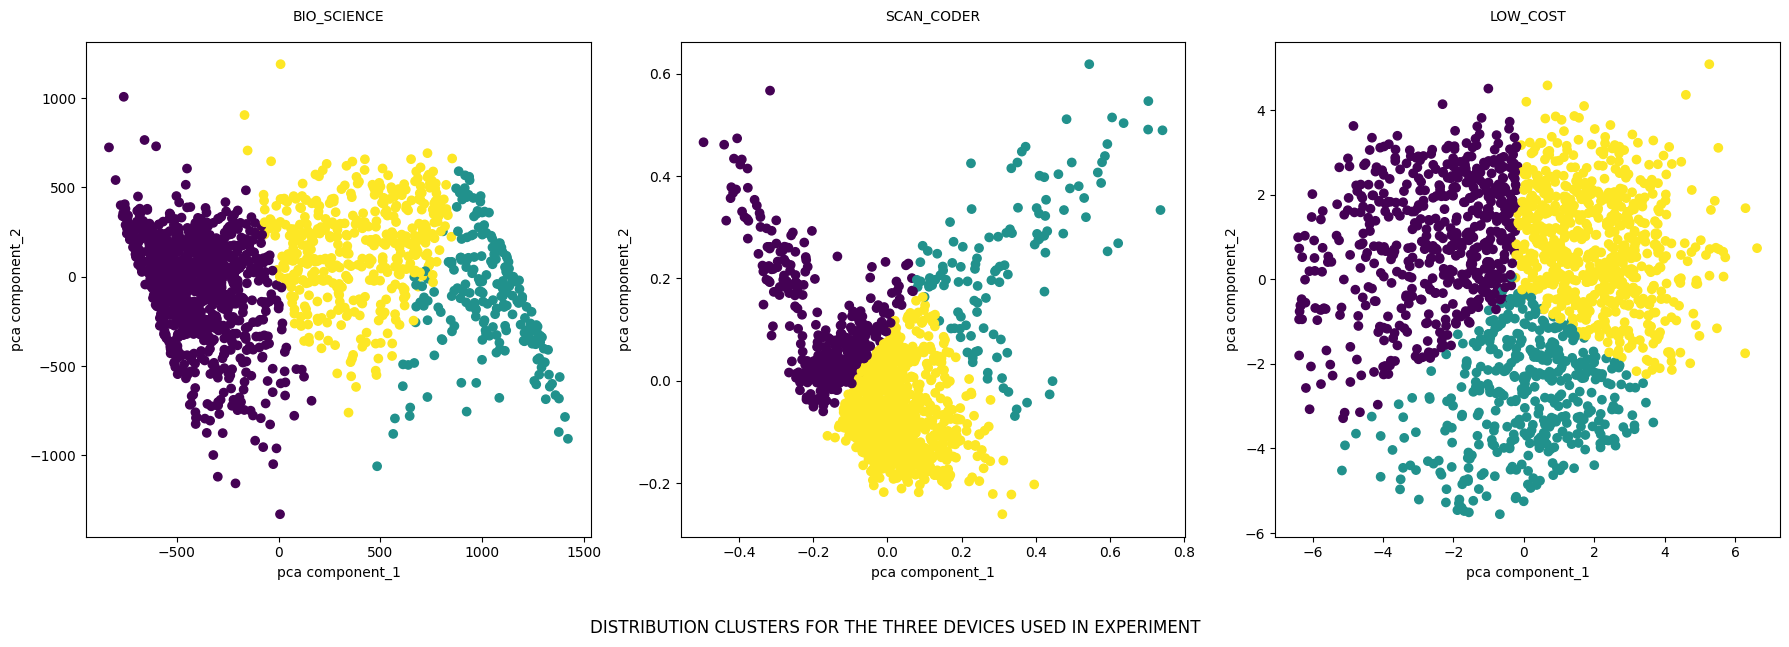

In [24]:
_keys = list(state_dict.keys())
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes = axes.flatten()

for i, _key in enumerate(state_dict.keys()):
    res_dict = state_dict[_key]
    labels, x_pca = res_dict['labels'], res_dict['pca_components']
    axes[i].scatter(x_pca[:, 0], x_pca[:, 1], c=labels)
    axes[i].set_xlabel('pca component_1')
    axes[i].set_ylabel('pca component_2')
    axes[i].set_title(_key, pad=15, fontsize=10)
plt.tight_layout()
fig.savefig('device_visualization.png')
fig.suptitle("DISTRIBUTION CLUSTERS FOR THE THREE DEVICES USED IN EXPERIMENT", fontsize=12, y=-0.04)
plt.show()